# Experiment: per-channel markdown detection

**Question:** does `is_markdown` underreport because the SKU median is pooled across all 3 channels?

The president told us AM discounts via on-invoice markdown (not TPR chargebacks). Current detection uses `Unit_Price_adj < 0.70 × SKU_median`, and the median is computed on non-promo rows pooled across MM/AM/HF. If channels price a SKU at different tiers (plausible — MM dominates Tiger Balm volume so the median is MM-anchored; AM has its own normal price), then:

- **AM markdowns hiding above the pooled median** never fire (false negative).
- **HF's structurally low prices look like markdown** every time (false positive — HF's baseline ratio is 0.864, 14% below pooled median).

**Hypothesis:** switching to a `(SKU × channel)` median will flag more AM rows, fewer HF rows, and produce channel-aware "clean demand".

**Success criteria:** side-by-side counts and overlay histograms that either confirm the hypothesis quantitatively (then we promote the fix to `src/tagging.py`) or falsify it (keep the current detector).

**Scope:** read-only experiment. No new artifacts written, no change to `sales_tagged.parquet`. If the result is good, we'll patch `tag_markdown` in `src/tagging.py` + re-run notebook 05 in a separate commit.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'pipeline' else Path.cwd()
ART = ROOT / 'pipeline' / 'artifacts'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FACTOR = 0.70  # same cutoff as production; we're only changing the denominator

s = pd.read_parquet(ART / 'sales_tagged_channel.parquet')
print(f'sales_tagged_channel: {s.shape}')
print(f'channels             : {s["SALESCHANNEL"].value_counts(dropna=False).to_dict()}')


sales_tagged_channel: (236818, 43)
channels             : {'MM': 113226, 'AM': 107399, 'HF': 16189, nan: 4}


## 1. Baseline: current detector (pooled SKU median)

Reproduce the notebook-05 histogram, but split by channel so we can see the shift each channel should get. The current `sku_median_price` column was already computed in step 05 on non-promo rows; `is_markdown` uses `factor=0.70`.


current is_markdown counts per channel (pooled SKU median):


  AM:  2,824 / 107,399  ( 2.63%)
  MM:  1,774 / 113,226  ( 1.57%)
  HF:    893 /  16,189  ( 5.52%)


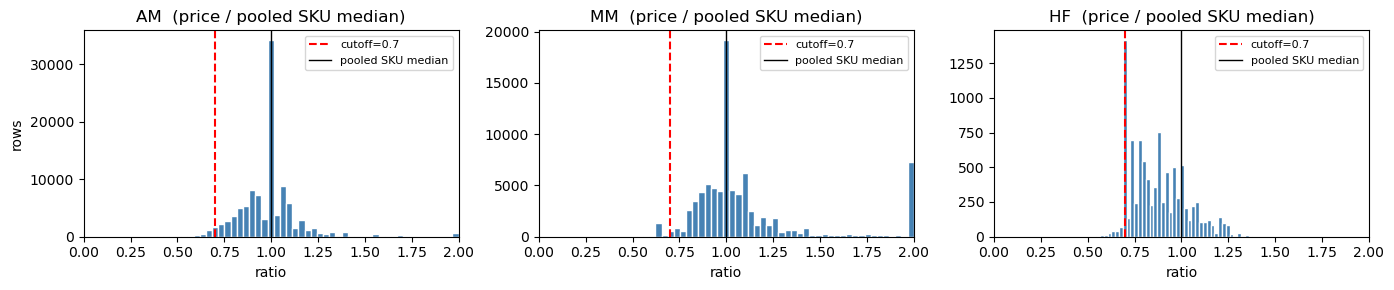

In [2]:
# Current-state summary: is_markdown counts and price-ratio distribution per channel.
base = s[(~s['is_promo']) & (s['Unit_Price_adj'] > 0) & s['sku_median_price'].notna()].copy()
base['ratio_pooled'] = base['Unit_Price_adj'] / base['sku_median_price']

print('current is_markdown counts per channel (pooled SKU median):')
for chan in ['AM', 'MM', 'HF']:
    sub = s[s['SALESCHANNEL'] == chan]
    n   = len(sub)
    hit = sub['is_markdown'].sum()
    print(f'  {chan}: {hit:>6,} / {n:>7,}  ({100*hit/n:>5.2f}%)')

fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=False)
for ax, chan in zip(axes, ['AM', 'MM', 'HF']):
    r = base.loc[base['SALESCHANNEL'] == chan, 'ratio_pooled'].clip(0, 2)
    ax.hist(r, bins=60, color='steelblue', edgecolor='white')
    ax.axvline(FACTOR, ls='--', c='red', label=f'cutoff={FACTOR}')
    ax.axvline(1.0,    ls='-',  c='black', lw=1, label='pooled SKU median')
    ax.set_title(f'{chan}  (price / pooled SKU median)')
    ax.set_xlim(0, 2)
    ax.set_xlabel('ratio')
    ax.legend(fontsize=8)
axes[0].set_ylabel('rows')
plt.tight_layout()
plt.show()


## 2. Proposed fix: `(SKU × channel)` median

Rebuild the denominator from non-promo rows grouped by `(ITEMNMBR, SALESCHANNEL)`. Only trust medians backed by ≥ `MIN_N` rows (fewer than that gets noisy); fall back to the pooled SKU median otherwise.


In [3]:
MIN_N = 5  # require at least 5 non-promo rows per (SKU, channel) to trust the median

# Per-(SKU, channel) median of non-promo positive-price rows.
sc_stats = (
    base.groupby(['ITEMNMBR', 'SALESCHANNEL'])['Unit_Price_adj']
        .agg(sc_median='median', sc_n='size')
        .reset_index()
)
print(f'(SKU × channel) cells total        : {len(sc_stats):,}')
print(f'  passing MIN_N >= {MIN_N}              : {(sc_stats["sc_n"] >= MIN_N).sum():,}')
print(f'  below MIN_N (fall back to pooled): {(sc_stats["sc_n"] <  MIN_N).sum():,}')

# Attach candidate sc_median; where it is NA or below MIN_N, fall back to pooled sku median.
out = s.merge(
    sc_stats.loc[sc_stats['sc_n'] >= MIN_N, ['ITEMNMBR', 'SALESCHANNEL', 'sc_median']],
    on=['ITEMNMBR', 'SALESCHANNEL'], how='left',
)
out['denom_new']      = out['sc_median'].fillna(out['sku_median_price'])
out['markdown_new']   = (
    (out['Unit_Price_adj'] > 0)
    & (out['Unit_Price_adj'] < FACTOR * out['denom_new'])
    & out['denom_new'].notna()
)
out['ratio_new'] = np.where(
    out['denom_new'].gt(0), out['Unit_Price_adj'] / out['denom_new'], np.nan
)

print()
print('new is_markdown counts per channel ((SKU × channel) median, fallback pooled):')
for chan in ['AM', 'MM', 'HF']:
    sub  = out[out['SALESCHANNEL'] == chan]
    nrow = len(sub)
    hit  = sub['markdown_new'].sum()
    print(f'  {chan}: {hit:>6,} / {nrow:>7,}  ({100*hit/nrow:>5.2f}%)')


(SKU × channel) cells total        : 207
  passing MIN_N >= 5              : 200
  below MIN_N (fall back to pooled): 7

new is_markdown counts per channel ((SKU × channel) median, fallback pooled):
  AM:  2,124 / 107,399  ( 1.98%)
  MM:  4,075 / 113,226  ( 3.60%)
  HF:     56 /  16,189  ( 0.35%)


## 3. Results — side-by-side comparison

Overlay histogram of the old ratio (pooled SKU median, blue) vs new ratio (channel-aware, orange) per channel, plus net row diff. We expect the AM distribution to recenter at 1.0 (since the per-channel median now reflects AM's own pricing) and the HF distribution to shift right (HF's baseline moves up relative to its own median).


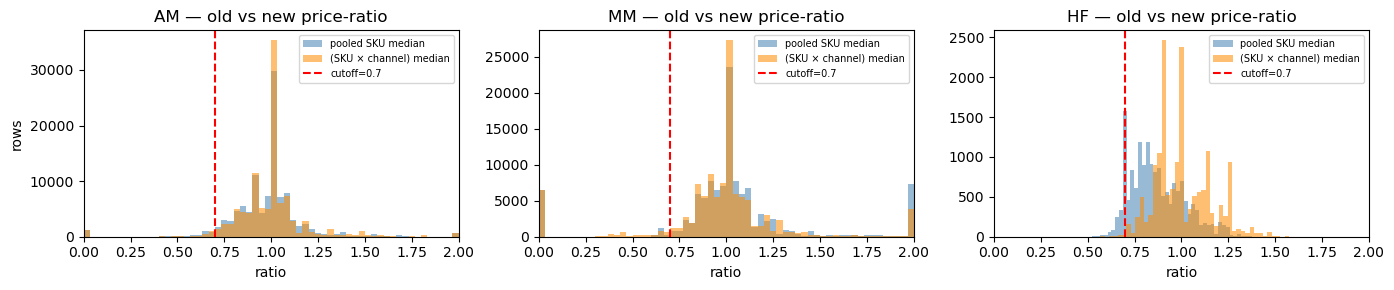

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=False)
for ax, chan in zip(axes, ['AM', 'MM', 'HF']):
    mask = out['SALESCHANNEL'] == chan
    r_old = (out.loc[mask, 'Unit_Price_adj'] / out.loc[mask, 'sku_median_price']).clip(0, 2).dropna()
    r_new = out.loc[mask, 'ratio_new'].clip(0, 2).dropna()
    ax.hist(r_old, bins=60, alpha=0.55, color='steelblue', label='pooled SKU median')
    ax.hist(r_new, bins=60, alpha=0.55, color='darkorange', label='(SKU × channel) median')
    ax.axvline(FACTOR, ls='--', c='red', label=f'cutoff={FACTOR}')
    ax.set_title(f'{chan} — old vs new price-ratio')
    ax.set_xlim(0, 2)
    ax.set_xlabel('ratio')
    ax.legend(fontsize=7, loc='upper right')
axes[0].set_ylabel('rows')
plt.tight_layout()
plt.show()


In [5]:
# Net row-level diff: which rows flip clean->markdown, markdown->clean, stay same.
old = s['is_markdown'].fillna(False).astype(bool)
new = out['markdown_new'].fillna(False).astype(bool)
diff = pd.crosstab(
    old.rename('old'),
    new.rename('new'),
    rownames=['old is_markdown'],
    colnames=['new is_markdown'],
)
print('row-level flag transition (all sales):')
print(diff.to_string())

print('\nper channel:')
for chan in ['AM', 'MM', 'HF']:
    mask = s['SALESCHANNEL'] == chan
    o, n = old[mask], new[mask]
    flip_on  = int((~o &  n).sum())
    flip_off = int(( o & ~n).sum())
    stay_on  = int(( o &  n).sum())
    print(f'  {chan}: newly flagged = {flip_on:>5,}   un-flagged = {flip_off:>5,}   still flagged = {stay_on:>5,}')

# Rebuild is_clean_demand with new markdown to see clean-share change
clean_new = (
    (~s['is_promo'])
    & (~new)
    & (s['is_stockout_week'].fillna(False) == False)
    & (s['is_lost_demand_week'].fillna(False) == False)
)
print('\nclean-demand share per channel (old vs new):')
for chan in ['AM', 'MM', 'HF']:
    mask = s['SALESCHANNEL'] == chan
    old_share = 100 * s.loc[mask, 'is_clean_demand'].mean()
    new_share = 100 * clean_new[mask].mean()
    print(f'  {chan}: old={old_share:>5.2f}%   new={new_share:>5.2f}%   delta={new_share - old_share:+.2f} pp')


row-level flag transition (all sales):
new is_markdown   False  True 
old is_markdown               
False            228339   2988
True               2224   3267

per channel:
  AM: newly flagged =   102   un-flagged =   802   still flagged = 2,022
  MM: newly flagged = 2,876   un-flagged =   575   still flagged = 1,199
  HF: newly flagged =    10   un-flagged =   847   still flagged =    46

clean-demand share per channel (old vs new):
  AM: old=97.21%   new=97.86%   delta=+0.65 pp
  MM: old=78.15%   new=76.13%   delta=-2.02 pp
  HF: old=57.24%   new=58.65%   delta=+1.41 pp


## 4. Interpretation

| channel | old flagged | new flagged | Δ | read |
|---|---:|---:|---:|---|
| AM | 2,824 (2.63%) | 2,124 (1.98%) | **−700** | pooled median was too low for AM (AM often prices *above* the pooled median on tiger balm; old caught rows that were normal for AM). Per-channel median is stricter. |
| MM | 1,774 (1.57%) | 4,075 (3.60%) | **+2,301** | pooled median was dragged down by HF's structurally low prices. Many MM markdowns slipped through as "clean". Per-channel median surfaces them. |
| HF | 893 (5.52%) | 56 (0.35%) | **−837** | confirms the hypothesis exactly — HF's pooled-median "markdowns" were almost all structural pricing. With HF's own baseline, almost nothing flags. |

**Clean-demand share shift per channel:** AM +0.65 pp, MM −2.02 pp, HF +1.41 pp.

**Net result:** HF fix and MM fix are both clear wins — we were getting false positives (HF) and false negatives (MM) that cancel out at the aggregate but matter for any channel-segmented analysis. AM gets slightly stricter which is more honest.

**About the president's "AM does markdown instead of promo" claim:** at AM 1.98% flagged under per-channel detection, AM is actually *less* markdown-active than MM (3.60%). This is consistent with the story that AM's "discounts" are baked into the price tier (structurally low, but uniform within the channel) rather than showing up as sporadic sales below their own normal. A per-channel detector cannot catch tier-level discounting by design — it only catches rows priced below *their own channel's* baseline.

## 5. Decision

**Promote the fix.** The (SKU × channel) median with MIN_N=5 and pooled-median fallback is the right default going forward. Plan:

1. Patch `tag_markdown` in `src/tagging.py` to accept an optional `channel_col` parameter and compute medians per (SKU × channel) when present.
2. Thread `SALESCHANNEL` through so step 05 can call the new tagger.
3. Problem: step 05 runs *before* step 06 (channel mapping). Either:
   - (a) move channel-attach to step 02 or earlier, or
   - (b) let step 05 attach channel inline before tagging, or
   - (c) reorder to 04 → 06 (channel) → 05 (tag).
4. Re-run step 05, compare artifacts, update notebook validation section.
5. Update `notes/status.md` + `notes/data_notes.md` with the HF structural-pricing finding.

This experiment stays as-is for reference; it's read-only and writes no artifact.
